# InSTAnT: sub-cellular colocalization (sc-instant)

Analyza d-kolokalizacie genovych parov z Xenium / ProSeg transkriptov pomocou balika **sc-instant**
(Kumar et al., *Nat. Commun.* 2024; [github.com/bhavaygg/InSTAnT](https://github.com/bhavaygg/InSTAnT)).

Pipeline:
1. **Proximal Pairs (PP) test** v kazdej bunke: su transkripty genov *i* a *j* blizsie ako `DISTANCE_UM` castejsie, nez by sa cakalo z hustoty transkriptov bunky? (binomicky test, `InSTAnT.ProximalPairs`)
2. **Global colocalization (CPB test)**: je par kolokalizovany v signifikantne vela bunkach? (Conditional Poisson-Binomial, `InSTAnT.ConditionalGlobalColocalization`)
3. **Partneri `ANCHOR_GENE`**: tabulka + 5 x 5 grid top kolokalizovanych genov + prehlad cez vzorky.

Poznamka k Windows: `Instant.run_ProximalPairs()` a `Instant.run_GlobalColocalization()` pouzivaju `multiprocessing` s globalnymi
premennymi modulu, ktore na Windows (spawn) worker procesy nevidia, a spustaju novy proces pre kazdu bunku. Preto volame priamo
triedy balika (`ProximalPairs`, `ConditionalGlobalColocalization`, `Instant`) a paralelizujeme cez `joblib`. Statistika je identicka s balikom.

In [1]:
import json
import warnings

import numpy as np
import pandas as pd
import scanpy as sc
import matplotlib.pyplot as plt
import pyarrow.parquet as pq
from scipy import stats
from joblib import Parallel, delayed
from matplotlib.colors import LinearSegmentedColormap

import InSTAnT.InSTAnT as ist
from InSTAnT.InSTAnT import Instant, ProximalPairs, ConditionalGlobalColocalization

In [2]:
import utils.paths as d
import utils.utils as u

In [3]:
d.instant_dir.mkdir(parents=True, exist_ok=True)
d.instant_figdir.mkdir(parents=True, exist_ok=True)
print(d.instant_dir)
print(d.instant_figdir)

C:\Users\sevco\Documents\phd\proj_2026_Zimcik_Xenium\Xenium_Analysis_SATB2_UMG_2026\results\07_instant
C:\Users\sevco\Documents\phd\proj_2026_Zimcik_Xenium\Xenium_Analysis_SATB2_UMG_2026\figures\07_instant


# Data

Parametre:
- `SAMPLES` - vzorky, na ktorych InSTAnT pustime
- `ZARR_DIR` - adresar s `<sample>.zarr` (ProSeg transkripty, `assignment` == `adata.obs["cell"]`)
- `CELL_TYPES` - `None` = vsetky bunky, alebo zoznam anotacii z `adata.obs["annotation"]` (napr. len osteogenne typy)
- `MAX_CELLS` - nahodny vyber buniek na vzorku (`None` = vsetky). Pamat PP matice je `n_cells * N_GENES^2 * 8 B`
  (5 000 buniek x 100 genov ~ 0.4 GB; pocas CPB testu su v pamati ~4 take matice)
- `MIN_QV` - Xenium quality filter transkriptov
- `MIN_TRANSCRIPTS` - InSTAnT `min_genecount`: bunky s `<=` tolkymi transkriptmi sa vynechaju
- `SEED` - seed pre nahodny vyber buniek

In [4]:
SAMPLES         = ["wt_1", "wt_2", "wt_3", "wt_4", "mut_1", "mut_2", "mut_3", "mut_4"]
ZARR_DIR        = d.preprocessed_dir
CELL_TYPES      = None       # e.g. ["Osteogenic progenitors", "Early osteoblasts"]
MAX_CELLS       = 5000       # per sample; None = all cells
MIN_QV          = 20
MIN_TRANSCRIPTS = 20
SEED            = 42

In [5]:
adata = sc.read_h5ad(d.preprocessed_dir / "adata_annotated_refined_10.h5ad")
adatas = {s: adata[adata.obs["sample"] == s].copy() for s in SAMPLES}
print({s: a.n_obs for s, a in adatas.items()})
assert all(a.n_obs > 0 for a in adatas.values()), "empty sample in adatas"

if CELL_TYPES is not None:
    missing = set(CELL_TYPES) - set(adata.obs["annotation"].cat.categories)
    assert not missing, f"not found in annotation: {missing}"

c:\Users\sevco\Documents\diplomka\DiplomaThesis\venv\Lib\site-packages\anndata\_core\anndata.py:1882: UserWarning: Observation names are not unique. To make them unique, call `.obs_names_make_unique`.
  utils.warn_names_duplicates("obs")


{'wt_1': 26871, 'wt_2': 24828, 'wt_3': 22654, 'wt_4': 30322, 'mut_1': 21469, 'mut_2': 23470, 'mut_3': 25948, 'mut_4': 25163}


## Transcripts

Transkripty prevedieme do InSTAnT formatu `['gene', 'uID', 'absX', 'absY']`; `uID` = pozicia bunky v `adatas[sample]`.
Pouzivame vsetky transkripty bunky (vsetky geny panelu), takze pozadie PP testu (pravdepodobnost blizkosti dvoch transkriptov v bunke)
je odhadnute z celej bunky, aj ked testujeme iba `N_GENES` genov.

In [6]:
def load_transcripts(sample, ad, min_qv=MIN_QV):
    # Assigned, non-background transcripts of the cells in `ad`, in InSTAnT format (uID = row of `ad`)
    tbl = pq.read_table(ZARR_DIR / f"{sample}.zarr" / "points" / "transcripts" / "points.parquet",
                        columns=["x", "y", "gene", "assignment", "background", "qv"])
    tx = tbl.to_pandas()
    tx = tx[tx["assignment"].notna() & ~tx["background"].astype(bool) & (tx["qv"] >= min_qv)]
    cell_pos = pd.Series(np.arange(ad.n_obs), index=ad.obs["cell"].astype(np.int64).to_numpy())
    uid = cell_pos.reindex(tx["assignment"].to_numpy(np.int64)).to_numpy()
    keep = ~np.isnan(uid) & tx["gene"].isin(ad.var_names).to_numpy()
    return pd.DataFrame({
        "gene": tx["gene"].to_numpy()[keep].astype(str),
        "uID": uid[keep].astype(np.int64),
        "absX": tx["x"].to_numpy(np.float64)[keep],
        "absY": tx["y"].to_numpy(np.float64)[keep],
    })


def select_cells(ad, rng):
    # Rows of `ad` to analyse: optional cell-type filter, then random subsample
    idx = np.arange(ad.n_obs)
    if CELL_TYPES is not None:
        idx = idx[ad.obs["annotation"].isin(CELL_TYPES).to_numpy()]
    if MAX_CELLS is not None and idx.size > MAX_CELLS:
        idx = np.sort(rng.choice(idx, MAX_CELLS, replace=False))
    return idx

In [7]:
rng = np.random.default_rng(SEED)
tx, tx_report = {}, {}

for s in SAMPLES:
    t = load_transcripts(s, adatas[s])
    t = t[t["uID"].isin(select_cells(adatas[s], rng))]
    n_per_cell = t.groupby("uID").size()
    t = t[t["uID"].isin(n_per_cell.index[n_per_cell > MIN_TRANSCRIPTS])].reset_index(drop=True)
    tx[s] = t
    tx_report[s] = {"n_cells": t["uID"].nunique(), "n_transcripts": len(t),
                    "median_transcripts_per_cell": t.groupby("uID").size().median()}

pd.DataFrame(tx_report).T

,n_cells,n_transcripts,median_transcripts_per_cell
wt_1,4996.0,1608543.0,260.0
wt_2,4997.0,1604645.0,271.0
wt_3,4999.0,1367516.0,222.0
wt_4,4996.0,1580650.0,264.0
mut_1,4994.0,1321243.0,229.0
mut_2,4999.0,1339742.0,217.0
mut_3,4998.0,1421541.0,236.0
mut_4,4999.0,1277125.0,217.0


# Gene selection

InSTAnT drzi pre kazdu bunku maticu `N_GENES x N_GENES`, preto testujeme podmnozinu panelu (spolocnu pre vsetky vzorky, aby boli vysledky porovnatelne).

Parametre:
- `ANCHOR_GENE` - gen, ktoreho kolokalizacnych partnerov hladame
- `N_GENES` - pocet testovanych genov (vratane `ANCHOR_GENE`); cas PP testu rastie ~ `N_GENES^2`
- `GENE_SELECTION` - `"coexpressed"` = geny v najviac bunkach spolu s `ANCHOR_GENE` (zamerane na partnerov anchor genu),
  `"expressed"` = najviac transkriptov celkovo (globalny pohlad)
- `EXTRA_GENES` - geny, ktore chceme testovat vzdy (napr. zname markery)

In [8]:
ANCHOR_GENE    = "Satb2"
N_GENES        = 100
GENE_SELECTION = "coexpressed"   # "coexpressed" or "expressed"
EXTRA_GENES    = []

In [9]:
assert ANCHOR_GENE in adata.var_names, f"{ANCHOR_GENE} not in the panel"
missing = set(EXTRA_GENES) - set(adata.var_names)
assert not missing, f"not in the panel: {missing}"
assert GENE_SELECTION in ("coexpressed", "expressed"), GENE_SELECTION

# gene x cell presence, pooled over samples
cell_gene = pd.concat([t.groupby(["uID", "gene"]).size().rename("n").reset_index().assign(sample=s)
                       for s, t in tx.items()], ignore_index=True)
if GENE_SELECTION == "expressed":
    score = cell_gene.groupby("gene")["n"].sum()
else:
    anchor_cells = cell_gene.loc[cell_gene["gene"] == ANCHOR_GENE, ["sample", "uID"]]
    score = cell_gene.merge(anchor_cells, on=["sample", "uID"]).groupby("gene").size()
score = score.drop([ANCHOR_GENE, *EXTRA_GENES], errors="ignore").sort_values(ascending=False)

forced = list(dict.fromkeys([ANCHOR_GENE, *EXTRA_GENES]))
gene_list = np.array(sorted(forced + score.index[:max(N_GENES - len(forced), 0)].tolist()))
anchor_idx = int(np.flatnonzero(gene_list == ANCHOR_GENE)[0])

n_cells_total = sum(t["uID"].nunique() for t in tx.values())
n_anchor = (cell_gene["gene"] == ANCHOR_GENE).sum()
print(f"{len(gene_list)} genes ({GENE_SELECTION}); {ANCHOR_GENE} present in {n_anchor}/{n_cells_total} cells "
      f"({n_anchor / n_cells_total:.1%})")
print(", ".join(gene_list))

100 genes (coexpressed); Satb2 present in 5260/39978 cells (13.2%)
Acly, Actc1, Actn1, Aldoa, Alpl, Atp5o, Bin1, Bmp1, Cacna1g, Ccnd2, Cdh11, Cdh2, Cercam, Col1a1, Col1a2, Col5a1, Col6a2, Col6a3, Ddit4, Dlx5, Dnm1, Dpysl2, Elmo1, Emilin1, Fat1, Fat4, Fbn1, Fgfr1, Fgfr2, Fgfr3, Fn1, Gja1, Gpc4, H2afz, Hist2h2bb, Hspg2, Ibsp, Igdcc4, Irs1, Jpt1, Kif1c, Lmnb1, Lox, Lum, Map1b, Map4, Mef2d, Mmp2, Msn, Ncam1, Ndn, Notch2, Nrp2, P3h1, Pard3, Pdgfra, Pgk1, Pik3r1, Pkm, Plagl1, Plec, Postn, Prkaca, Prkar1a, Prpf19, Prrx1, Ptch1, Pth1r, Raf1, Rai14, Rcor2, Rnaset2a, Rnh1, Robo1, Runx2, Satb2, Sdc1, Sdha, Sdhb, Sec61a1, Serpine2, Sgms2, Slit3, Smtn, Sox4, Sp7, Tbx2, Tcf7, Thbs1, Thbs2, Tmem119, Tnc, Tpcn1, Tpi1, Vcan, Vcl, Vdac1, Wif1, Ybx3, Zeb2


# Proximal Pairs test (per cell)

Pre kazdu bunku `InSTAnT.ProximalPairs`: $p_0$ = podiel vsetkych parov transkriptov bunky blizsie ako $d$,
$p_{ijc} = P\big(\mathrm{Binom}(n_i n_j,\ p_0) \ge K_{ij}\big)$.

Parametre:
- `DISTANCE_UM` - $d$: dva transkripty su "proximal", ak su blizsie ako tato vzdialenost (um)
- `N_JOBS` - pocet paralelnych procesov
- `CELLS_PER_TASK` - kolko buniek spracuje jeden joblib task (mensie = rovnomernejsia zataz, vacsie = menej overheadu)

In [10]:
DISTANCE_UM    = 2.0
N_JOBS         = 8
CELLS_PER_TASK = 200

In [11]:
def _pp_block(cells, gene_list, distance):
    # InSTAnT PP test for a block of cells, each given as (xy, gene labels of its transcripts)
    warnings.simplefilter("ignore")   # pandas fragmentation warnings inside ProximalPairs
    out = []
    for xy, genes in cells:
        pp = ProximalPairs(geneList=gene_list, df_loc=xy, distance_threshold=distance, mode="local", genes=genes)
        out.append((pp.p_vals, pp.genecount.to_numpy().ravel()))
    return out


def run_proximal_pairs(t, gene_list, distance=DISTANCE_UM):
    # Returns uIDs, p-values (n_cells, G, G) and gene counts (n_cells, G), as Instant.run_ProximalPairs()
    t = t.sort_values("uID", kind="stable")
    uids, start = np.unique(t["uID"].to_numpy(), return_index=True)
    bounds = np.append(start, len(t))
    xy, genes = t[["absX", "absY"]].to_numpy(), t["gene"].to_numpy()
    cells = [(xy[a:b], genes[a:b]) for a, b in zip(bounds[:-1], bounds[1:])]
    blocks = [cells[i:i + CELLS_PER_TASK] for i in range(0, len(cells), CELLS_PER_TASK)]
    out = Parallel(n_jobs=N_JOBS)(delayed(_pp_block)(b, gene_list, distance) for b in blocks)
    res = [r for block in out for r in block]
    return uids, np.stack([r[0] for r in res]), np.stack([r[1] for r in res])

# Global colocalization (CPB test)

`InSTAnT.ConditionalGlobalColocalization`: pocet buniek s $p_{ijc} <$ `ALPHA_CELLWISE` porovnany s Poisson-binomickym nullom.
Vystupna tabulka je `Instant._save_unstacked_pvals_adata()` (= "unstacked" tabulka z README), doplnena o `qval` (BH) a `enrichment` (pozorovane / ocakavane).

Parametre:
- `ALPHA_CELLWISE` - prah PP p-hodnoty, pri ktorom je par v bunke "kolokalizovany"
- `MIN_TRANSCRIPT` - InSTAnT `min_transcript`: bunka sa pre par pocita, ak oba geny maju `>` tolko transkriptov
- `HIGH_PRECISION` - presnejsie p-hodnoty v oblasti < 1e-13 (pomalsie)
- `FDR_ALPHA` - prah pre `qval`
- `RECOMPUTE` - `False` = nacitaj ulozene vysledky, ak boli spocitane s rovnakymi parametrami

In [12]:
ALPHA_CELLWISE = 0.05
MIN_TRANSCRIPT = 0
HIGH_PRECISION = False
FDR_ALPHA      = 0.05
RECOMPUTE      = False

In [13]:
def _cpb_block(model, obs_mat, pairs):
    ist.obs = obs_mat   # the package reads observed counts from a module global, which workers don't inherit
    return [model._compute_pval_serial(p) for p in pairs]


def run_global_colocalization(all_pval, all_gene_count, gene_list):
    # CPB test for all gene pairs; returns the InSTAnT "unstacked" table (one row per pair, i <= j)
    model = ConditionalGlobalColocalization(
        all_pvals=all_pval, transcript_count=all_gene_count, alpha_cellwise=ALPHA_CELLWISE,
        min_transcript=MIN_TRANSCRIPT, high_precision=HIGH_PRECISION, threads=1, precision_mode="high")
    model.pp_all_cells_local = model.prob_cells_coloc()
    G = len(gene_list)
    pairs = np.array([(i, j) for i in range(G) for j in range(i, G)])
    out = Parallel(n_jobs=N_JOBS)(delayed(_cpb_block)(model, ist.obs, b)
                                  for b in np.array_split(pairs, 4 * N_JOBS))
    glob, expected = np.ones((G, G)), np.zeros((G, G))
    for i, j, pval, exp in (r for block in out for r in block):
        glob[i, j] = glob[j, i] = pval
        expected[i, j] = expected[j, i] = exp
    ist.edge = ist.obs = None   # free the module-level copies

    obj = Instant(distance_threshold=DISTANCE_UM, threads=N_JOBS)
    obj.geneList, obj.all_pval, obj.all_gene_count = gene_list, all_pval, all_gene_count
    obj.global_coloc_df = pd.DataFrame(glob, index=gene_list, columns=gene_list)
    obj.expected_coloc_df = pd.DataFrame(expected, index=gene_list, columns=gene_list)
    return obj._save_unstacked_pvals_adata(ALPHA_CELLWISE, MIN_TRANSCRIPT)


def tidy_pairs(unstacked):
    # Gene pairs i < j with readable column names, BH q-values and observed / expected enrichment
    t = unstacked.reset_index(drop=True).rename(columns={
        "p_val_cond": "pval", "Expected coloc": "expected",
        f"Coloc. cells(Threshold<{ALPHA_CELLWISE})": "n_coloc_cells", "Present cells": "n_present_cells"})
    t = t[t["gene_id1"] != t["gene_id2"]].copy()
    t["pval"] = t["pval"].clip(1e-300, 1.0)   # PoiBin returns tiny negative values at underflow
    t["mlog10_p"] = -np.log10(t["pval"]) + 0.0   # + 0.0 turns -0.0 into 0.0
    t["qval"] = stats.false_discovery_control(t["pval"])
    t["enrichment"] = t["n_coloc_cells"] / t["expected"].clip(lower=1e-12)
    t[["n_coloc_cells", "n_present_cells"]] = t[["n_coloc_cells", "n_present_cells"]].astype(np.int64)
    return t.sort_values(["pval", "n_coloc_cells"], ascending=[True, False]).reset_index(drop=True)


def anchor_partners(pairs, anchor):
    # Pairs table re-oriented to `anchor` vs. every partner gene
    sub = pairs[(pairs["gene_id1"] == anchor) | (pairs["gene_id2"] == anchor)].copy()
    sub.insert(0, "partner", np.where(sub["gene_id1"] == anchor, sub["gene_id2"], sub["gene_id1"]))
    sub = sub.drop(columns=["gene_id1", "gene_id2"])
    return sub.sort_values(["pval", "n_coloc_cells"], ascending=[True, False]).reset_index(drop=True)

## Run all samples

Pre kazdu vzorku sa do `d.instant_dir / <sample>` ulozi:
- `pairs.csv` - vsetky testovane pary (CPB)
- `{ANCHOR_GENE}_partners.csv` - partneri anchor genu
- `{ANCHOR_GENE}_pp_pvals.parquet` - per-cell PP p-hodnota anchor x partner (bunky x geny), pre priestorove grafy
- `params.json` - parametre behu (ak sa zhoduju a `RECOMPUTE = False`, vysledky sa iba nacitaju)

In [14]:
params = {"genes": gene_list.tolist(), "anchor": ANCHOR_GENE, "distance_um": DISTANCE_UM,
          "alpha_cellwise": ALPHA_CELLWISE, "min_transcript": MIN_TRANSCRIPT, "high_precision": HIGH_PRECISION,
          "cell_types": CELL_TYPES, "max_cells": MAX_CELLS, "min_qv": MIN_QV,
          "min_transcripts": MIN_TRANSCRIPTS, "seed": SEED, "samples": SAMPLES}
results, report = {}, {}

for s in SAMPLES:
    out_dir = d.instant_dir / s
    out_dir.mkdir(parents=True, exist_ok=True)
    f_params = out_dir / "params.json"
    f_pairs, f_partners = out_dir / "pairs.csv", out_dir / f"{ANCHOR_GENE}_partners.csv"
    f_anchor = out_dir / f"{ANCHOR_GENE}_pp_pvals.parquet"

    cached = (not RECOMPUTE and f_params.exists() and json.loads(f_params.read_text()) == params
              and all(f.exists() for f in (f_pairs, f_partners, f_anchor)))
    if cached:
        pairs, partners, anchor_p = pd.read_csv(f_pairs), pd.read_csv(f_partners), pd.read_parquet(f_anchor)
        anchor_p.index = anchor_p.index.astype(np.int64)
    else:
        uids, all_pval, all_gene_count = run_proximal_pairs(tx[s], gene_list)
        pairs = tidy_pairs(run_global_colocalization(all_pval, all_gene_count, gene_list))
        partners = anchor_partners(pairs, ANCHOR_GENE)
        anchor_p = pd.DataFrame(all_pval[:, anchor_idx, :], index=pd.Index(uids, name="uID"), columns=gene_list)
        del all_pval, all_gene_count

        pairs.to_csv(f_pairs, index=False)
        partners.to_csv(f_partners, index=False)
        anchor_p.to_parquet(f_anchor)
        f_params.write_text(json.dumps(params, indent=1))

    results[s] = {"pairs": pairs, "partners": partners, "anchor_p": anchor_p}
    report[s] = {"n_cells": len(anchor_p), "pairs_tested": len(pairs),
                 f"pairs_q<{FDR_ALPHA}": int((pairs["qval"] < FDR_ALPHA).sum()),
                 f"{ANCHOR_GENE}_partners_q<{FDR_ALPHA}": int((partners["qval"] < FDR_ALPHA).sum()),
                 "loaded_from_cache": cached}
    print(s, report[s])

report = pd.DataFrame(report).T
report

Number of cells: 4996, Number of genes: 100
Global Colocalization initialized ..
wt_1 {'n_cells': 4996, 'pairs_tested': 4950, 'pairs_q<0.05': 3650, 'Satb2_partners_q<0.05': 80, 'loaded_from_cache': False}
Number of cells: 4997, Number of genes: 100
Global Colocalization initialized ..
wt_2 {'n_cells': 4997, 'pairs_tested': 4950, 'pairs_q<0.05': 3727, 'Satb2_partners_q<0.05': 76, 'loaded_from_cache': False}
Number of cells: 4999, Number of genes: 100
Global Colocalization initialized ..
wt_3 {'n_cells': 4999, 'pairs_tested': 4950, 'pairs_q<0.05': 3515, 'Satb2_partners_q<0.05': 69, 'loaded_from_cache': False}
Number of cells: 4996, Number of genes: 100
Global Colocalization initialized ..
wt_4 {'n_cells': 4996, 'pairs_tested': 4950, 'pairs_q<0.05': 3689, 'Satb2_partners_q<0.05': 79, 'loaded_from_cache': False}
Number of cells: 4994, Number of genes: 100
Global Colocalization initialized ..
mut_1 {'n_cells': 4994, 'pairs_tested': 4950, 'pairs_q<0.05': 3576, 'Satb2_partners_q<0.05': 49, 'l

,n_cells,pairs_tested,pairs_q<0.05,Satb2_partners_q<0.05,loaded_from_cache
wt_1,4996,4950,3650,80,False
wt_2,4997,4950,3727,76,False
wt_3,4999,4950,3515,69,False
wt_4,4996,4950,3689,79,False
mut_1,4994,4950,3576,49,False
mut_2,4999,4950,3523,48,False
mut_3,4998,4950,3440,40,False
mut_4,4999,4950,3424,40,False


In [15]:
results[SAMPLES[0]]["partners"].head(25)

,partner,pval,expected,n_coloc_cells,n_present_cells,frac_cells,mlog10_p,qval,enrichment
0,Rcor2,3.037570e-13,3.454754,24,517,0.046422,12.517474,4.176659e-11,6.946950
1,Alpl,5.720979e-13,10.147268,40,828,0.048309,12.242530,7.079712e-11,3.941948
2,Ibsp,4.342304e-12,6.293244,30,545,0.055046,11.362280,3.980446e-10,4.767016
3,Nrp2,1.330438e-09,6.103584,26,673,0.038633,8.876005,4.637794e-08,4.259792
4,Sp7,3.534890e-09,4.621600,22,672,0.032738,8.451624,1.066933e-07,4.760256
5,Tcf7,7.501894e-09,2.471407,16,544,0.029412,8.124829,2.051623e-07,6.474045
6,Tmem119,1.307156e-08,3.716384,19,568,0.033451,7.883673,3.278920e-07,5.112497
7,Thbs1,2.734599e-08,3.913029,19,491,0.038697,7.563106,6.016118e-07,4.855574
8,Ptch1,1.043804e-07,3.820170,18,607,0.029654,6.981381,1.688506e-06,4.711832
9,Cdh2,2.189192e-07,4.917602,20,673,0.029718,6.659716,3.035435e-06,4.067023


# Top partners of `ANCHOR_GENE`: 5 x 5 grid

Kazdy panel = jeden z top 25 partnerov `ANCHOR_GENE` (poradie podla CPB p-hodnoty, zlava doprava, zhora nadol).
Farebne su bunky, v ktorych je par `ANCHOR_GENE` x partner kolokalizovany (PP p < `ALPHA_CELLWISE`), farba = -log10 PP p.
Sede = vsetky bunky vzorky (pri `MAX_CELLS` sa testovala iba nahodna podmnozina).
Nadpis: poradie, gen, pocet kolokalizovanych / testovanych buniek, CPB q-hodnota.

Parametre:
- `PLOT_SAMPLE` - vzorka pre grid
- `GRID_ROWS`, `GRID_COLS` - rozmer gridu (5 x 5 = top 25)
- `MIN_COLOC_CELLS` - partner musi byt kolokalizovany aspon v tolkych bunkach (CPB null dava p ~ 0 aj parom s 1-2 bunkami, ak su geny inak malo kolokalizovane)
- `PP_VMAX` - horna hranica farebnej skaly (-log10 PP p)
- `POINT_SIZE` - velkost bodov kolokalizovanych buniek
- `SAVE_ALL_SAMPLES` - `True` = grid sa ulozi pre vsetky `SAMPLES`, zobrazi sa iba `PLOT_SAMPLE`

Pre každý gén sme počítali bunky, v ktorých sú transkripty Satb2 a daného génu bližšie ako 2 µm častejšie, než by sa čakalo z náhodného rozmiestnenia transkriptov v bunke. Údaj 24/517 znamená, že z 517 buniek exprimujúcich oba gény bola kolokalizácia významná v 24. Gény sú zoradené podľa toho, o koľko je tento počet vyšší než počet očakávaný pod nulovou hypotézou (CPB test, q-hodnota).

In [25]:
PLOT_SAMPLE      = "wt_1"
GRID_ROWS        = 5
GRID_COLS        = 5
MIN_COLOC_CELLS  = 5
PP_VMAX          = 3
POINT_SIZE       = 6
SAVE_ALL_SAMPLES = False

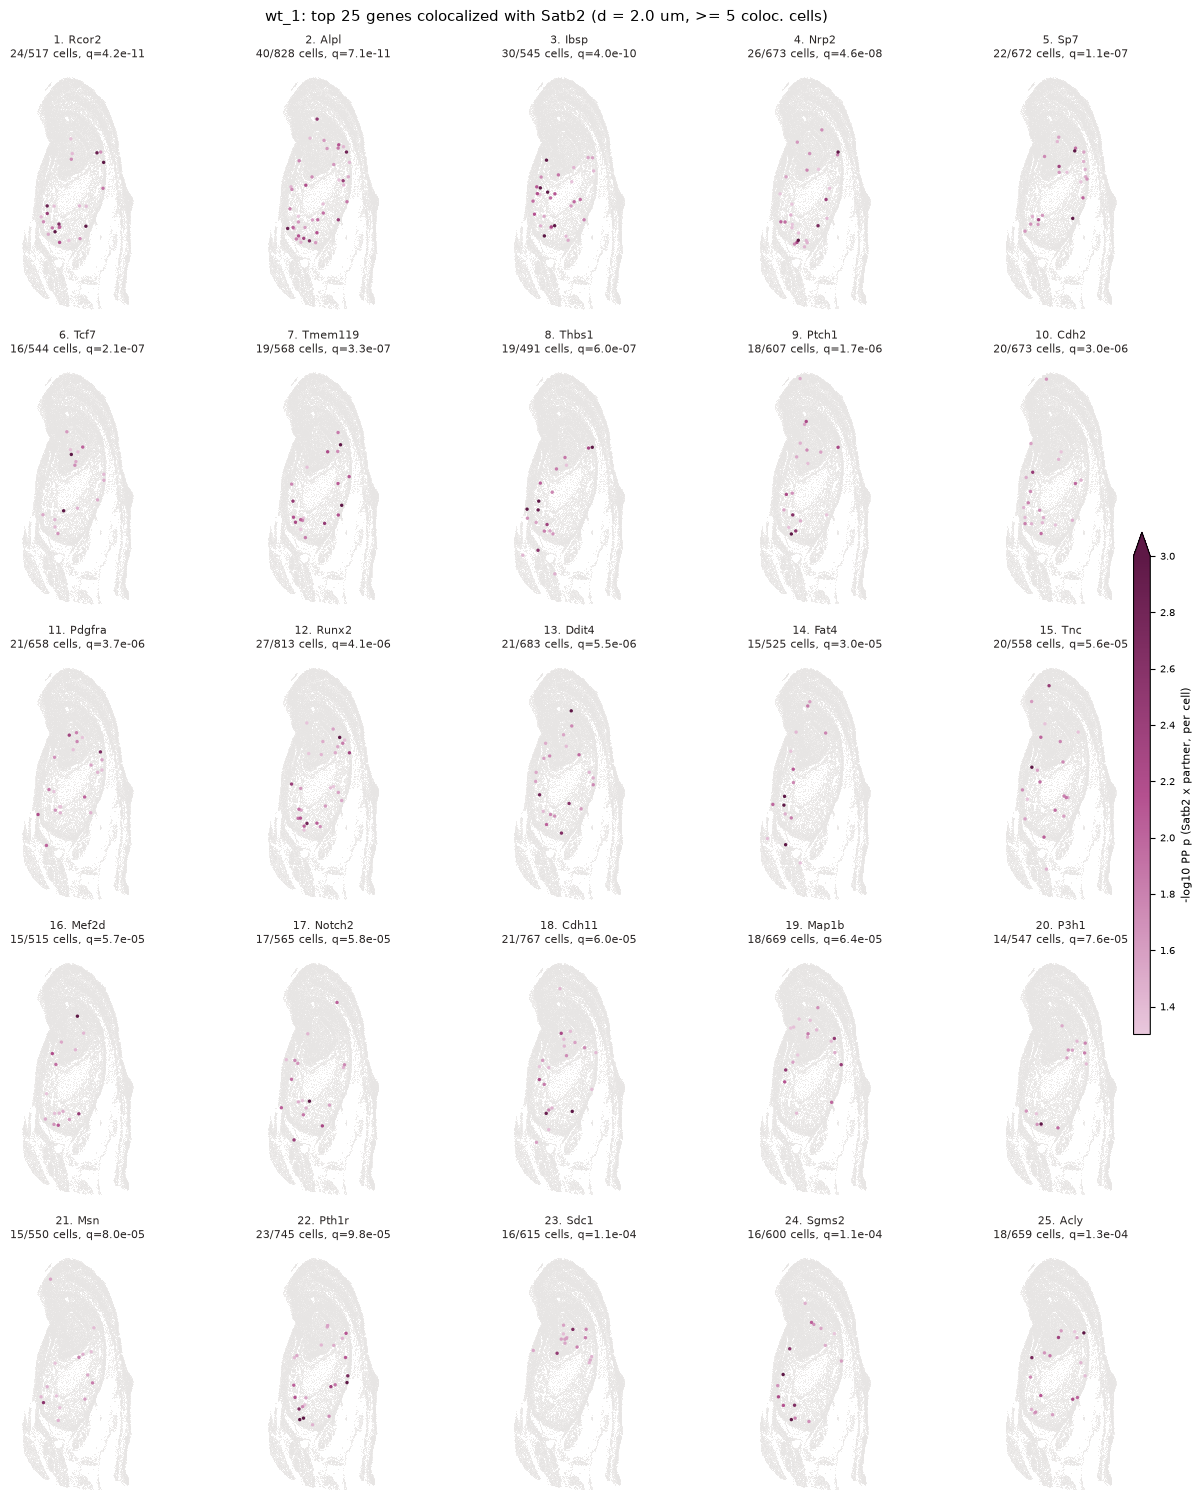

In [26]:
BG_GREY = "#E7E5E4"
CMAP_COLOC = LinearSegmentedColormap.from_list("coloc", ["#E9C8DD", "#B4508F", "#5E1846"])


def top_partners(sample, n):
    p = results[sample]["partners"]
    return p[p["n_coloc_cells"] >= MIN_COLOC_CELLS].head(n)


def plot_partner_grid(sample, n_rows=GRID_ROWS, n_cols=GRID_COLS):
    ad, anchor_p = adatas[sample], results[sample]["anchor_p"]
    xy_all = np.asarray(ad.obsm["spatial"])[:, :2]
    xy_tested = xy_all[anchor_p.index.to_numpy()]
    top = top_partners(sample, n_rows * n_cols)

    fig, axes = plt.subplots(n_rows, n_cols, figsize=(2.6 * n_cols, 3.0 * n_rows), constrained_layout=True)
    mappable = None
    for k, ax in enumerate(axes.flat):
        ax.set_axis_off()
        if k >= len(top):
            continue
        row = top.iloc[k]
        p = anchor_p[row["partner"]].to_numpy()
        sig = p < ALPHA_CELLWISE
        order = np.argsort(-p[sig])   # strongest cells drawn on top
        ax.scatter(xy_all[:, 0], xy_all[:, 1], s=0.3, c=BG_GREY, linewidths=0, rasterized=True)
        mappable = ax.scatter(xy_tested[sig][order, 0], xy_tested[sig][order, 1],
                              c=-np.log10(np.clip(p[sig][order], 1e-300, 1)), cmap=CMAP_COLOC,
                              vmin=-np.log10(ALPHA_CELLWISE), vmax=PP_VMAX,
                              s=POINT_SIZE, linewidths=0, rasterized=True)
        ax.set_aspect("equal")
        ax.set_title(f"{k + 1}. {row['partner']}\n"
                     f"{row['n_coloc_cells']}/{row['n_present_cells']} cells, q={row['qval']:.1e}",
                     fontsize=8, color="#292524")

    if mappable is not None:
        cb = fig.colorbar(mappable, ax=axes, shrink=0.35, aspect=30, pad=0.01, extend="max")
        cb.set_label(f"-log10 PP p ({ANCHOR_GENE} x partner, per cell)", fontsize=8)
        cb.ax.tick_params(labelsize=7)
    fig.suptitle(f"{sample}: top {len(top)} genes colocalized with {ANCHOR_GENE} "
                 f"(d = {DISTANCE_UM} um, >= {MIN_COLOC_CELLS} coloc. cells)", fontsize=11)
    return fig


for s in (SAMPLES if SAVE_ALL_SAMPLES else [PLOT_SAMPLE]):
    fig = plot_partner_grid(s)
    for ext in ("png", "pdf"):
        fig.savefig(d.instant_figdir / f"{ANCHOR_GENE}_top{GRID_ROWS * GRID_COLS}_partners_{s}.{ext}",
                    dpi=300, bbox_inches="tight")
    if s == PLOT_SAMPLE:
        plt.show()
    else:
        plt.close(fig)

# Replicate overview

Top partneri `ANCHOR_GENE` naprie vzorkami: -log10 CPB q-hodnota (bodka = q < `FDR_ALPHA`).
Riadky = zjednotenie top `N_HEATMAP` partnerov z kazdej vzorky, zoradene podla mediany q vo WT.

Parametre:
- `N_HEATMAP` - kolko top partnerov z kazdej vzorky vstupuje do prehladu
- `Q_VMAX` - horna hranica farebnej skaly (-log10 q)

In [18]:
N_HEATMAP = 10
Q_VMAX    = 10

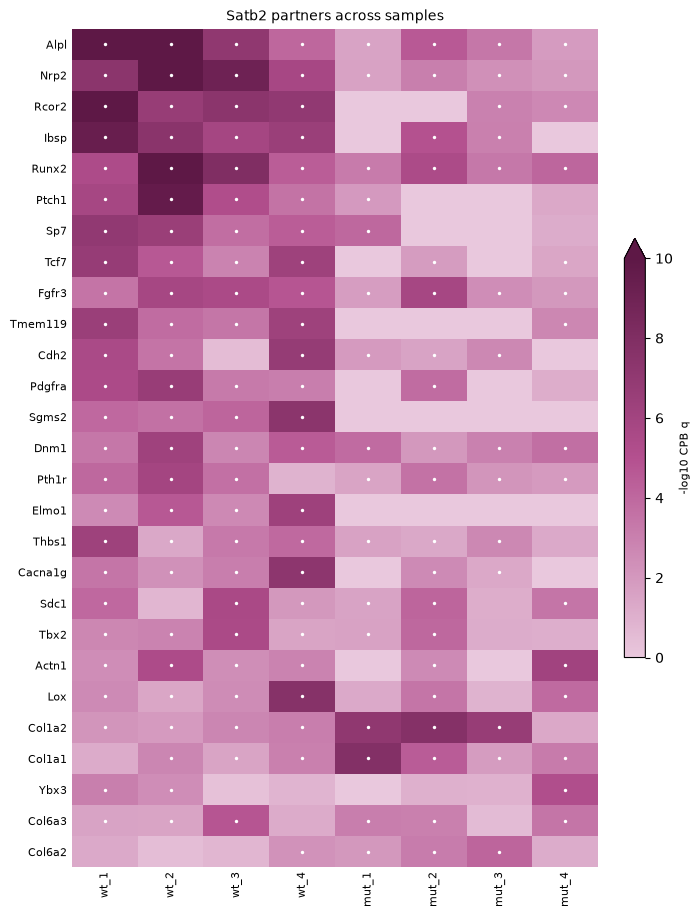

In [19]:
genes_hm = list(dict.fromkeys(g for s in SAMPLES for g in top_partners(s, N_HEATMAP)["partner"]))
mq = pd.DataFrame({s: results[s]["partners"].set_index("partner")["qval"].reindex(genes_hm) for s in SAMPLES})
mq = -np.log10(mq.clip(lower=1e-300))   # NaN = pair not tested in that sample
wt = [s for s in SAMPLES if s.startswith("wt")] or SAMPLES
mq = mq.loc[mq[wt].median(axis=1).sort_values(ascending=False).index]

fig, ax = plt.subplots(figsize=(0.55 * len(SAMPLES) + 2.5, 0.28 * len(mq) + 1.5), constrained_layout=True)
im = ax.imshow(mq.to_numpy(), cmap=CMAP_COLOC.with_extremes(bad=BG_GREY), vmin=0, vmax=Q_VMAX, aspect="auto")
yy, xx = np.nonzero(mq.to_numpy() > -np.log10(FDR_ALPHA))
ax.scatter(xx, yy, s=6, c="white", linewidths=0)
ax.set_xticks(range(len(SAMPLES)), SAMPLES, rotation=90, fontsize=8)
ax.set_yticks(range(len(mq)), mq.index, fontsize=8)
ax.tick_params(length=0)
for sp in ax.spines.values():
    sp.set_visible(False)
cb = fig.colorbar(im, ax=ax, shrink=0.5, extend="max")
cb.set_label("-log10 CPB q", fontsize=8)
ax.set_title(f"{ANCHOR_GENE} partners across samples", fontsize=10)
for ext in ("png", "pdf"):
    fig.savefig(d.instant_figdir / f"{ANCHOR_GENE}_partners_across_samples.{ext}", dpi=300, bbox_inches="tight")
plt.show()

In [20]:
# long table of all anchor partners, all samples
partners_all = pd.concat([results[s]["partners"].assign(sample=s) for s in SAMPLES], ignore_index=True)
partners_all.to_csv(d.instant_dir / f"{ANCHOR_GENE}_partners_all_samples.csv", index=False)
partners_all[partners_all["qval"] < FDR_ALPHA].groupby("partner").agg(
    n_samples_sig=("sample", "nunique"), median_frac_cells=("frac_cells", "median"),
    median_enrichment=("enrichment", "median")).sort_values("n_samples_sig", ascending=False).head(25)

,n_samples_sig,median_frac_cells,median_enrichment
partner,,,
Fgfr3,8,0.031281,12.443081
Dnm1,8,0.028734,11.296734
Alpl,8,0.034456,10.172840
Nrp2,8,0.034445,12.853608
Runx2,8,0.034787,17.824955
Postn,8,0.027315,5.713328
Col1a1,7,0.038961,7.451047
Col1a2,7,0.055238,1.624620
Fat1,7,0.026936,2.155646
